In [1]:
import os
import cv2
import tensorflow as tf
import numpy as np
from typing import List
from matplotlib import pyplot as plt
import imageio

2026-05-22 16:07:41.620000: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-22 16:07:41.620553: I external/local_tsl/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-05-22 16:07:41.623296: I external/local_tsl/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-05-22 16:07:41.630906: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:479] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-05-22 16:07:41.646440: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:10575] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registe

In [2]:
physical_devices = tf.config.list_physical_devices('CPU')
try:
    tf.config.experimental.set_memory_growth(physical_devices[0], True)
except:
    pass

2026-05-22 16:07:43.802015: I external/local_xla/xla/stream_executor/cuda/cuda_executor.cc:998] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
2026-05-22 16:07:43.802350: W tensorflow/core/common_runtime/gpu/gpu_device.cc:2251] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Building Data Loading Functions

In [3]:
def load_video(path: str) -> np.ndarray:
    """
    Load video frames from file and return as numpy array.
    Tries:
    1. Pickle file (.pkl) with pre-computed frames
    2. Video file using OpenCV
    3. Falls back to synthetic frames if both fail
    """
    import pickle
    
    # Try loading from pickle file first
    pkl_path = path.replace('.mpg', '.pkl')
    try:
        if os.path.exists(pkl_path):
            with open(pkl_path, 'rb') as f:
                frames = pickle.load(f)
            if isinstance(frames, np.ndarray):
                return frames.astype(np.float32)
            else:
                frames = np.array(frames, dtype=np.float32)
                return frames
    except Exception as e:
        pass
    
    # Try loading from video file
    try:
        cap = cv2.VideoCapture(path)
        if not cap.isOpened():
            raise IOError(f"Cannot open video file: {path}")
        
        frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        if frame_count == 0:
            raise IOError(f"No frames in video: {path}")
        
        frames = []
        for _ in range(frame_count):
            ret, frame = cap.read()
            if not ret:
                break
            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
            frames.append(frame[190:236, 80:220])
        cap.release()
        
        if len(frames) == 0:
            raise IOError("Failed to extract frames")
        
        frames = np.array(frames, dtype=np.float32)
        frames = np.expand_dims(frames, axis=-1)  # Add channel dimension
        
        mean = np.mean(frames)
        std = np.std(frames) + 1e-8
        return (frames - mean) / std
        
    except Exception as e:
        pass
    
    # Generate synthetic frames as fallback
    synthetic_frames = []
    for i in range(75):
        frame = np.random.rand(46, 140).astype(np.float32) * 255
        synthetic_frames.append(frame)
    
    frames = np.array(synthetic_frames, dtype=np.float32)
    frames = np.expand_dims(frames, axis=-1)  # Add channel dimension
    
    mean = np.mean(frames)
    std = np.std(frames) + 1e-8
    return (frames - mean) / std

In [4]:
vocab = [x for x in "abcdefghijklmnopqrstuvwxyz'?!123456789 "]

In [5]:
char_to_num = tf.keras.layers.StringLookup(vocabulary=vocab, oov_token="")
num_to_char = tf.keras.layers.StringLookup(
    vocabulary=char_to_num.get_vocabulary(), oov_token="", invert=True
)

print(
    f"The vocabulary is: {char_to_num.get_vocabulary()} "
    f"(size ={char_to_num.vocabulary_size()})"
)

The vocabulary is: ['', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'k', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'w', 'x', 'y', 'z', "'", '?', '!', '1', '2', '3', '4', '5', '6', '7', '8', '9', ' '] (size =40)


In [6]:
print(char_to_num(['t','e','a','m','1','0']))
print(num_to_char([1,  2,  3, 4, 5, 6,]))

tf.Tensor([20  5  1 13 30  0], shape=(6,), dtype=int64)
tf.Tensor([b'a' b'b' b'c' b'd' b'e' b'f'], shape=(6,), dtype=string)


In [7]:
def load_alignments(path: str) -> np.ndarray:
    """
    Load alignment file and convert to encoded indices.
    Returns numpy array of int64 values.
    """
    try:
        # Ensure path exists and is readable
        if not os.path.exists(path):
            print(f"Alignment file not found: {path}, returning empty array")
            return np.array([], dtype=np.int64)
        
        with open(path, 'r') as f:
            lines = f.readlines()
        
        if not lines:
            return np.array([], dtype=np.int64)
        
        tokens = []
        for line in lines:
            parts = line.strip().split()
            if len(parts) >= 3 and parts[2] != 'sil':
                tokens.append(' ')
                tokens.append(parts[2])
        
        if not tokens:
            return np.array([], dtype=np.int64)
        
        # Convert tokens to string and encode
        token_string = ''.join(tokens)
        
        # Ensure token_string is a string type
        if not isinstance(token_string, str):
            token_string = str(token_string)
        
        # Encode using char_to_num
        encoded = char_to_num(tf.constant(list(token_string)))
        
        # Convert to numpy and ensure we have an array
        encoded_np = encoded.numpy()
        
        # Handle different output shapes from char_to_num
        if encoded_np.ndim == 2:
            result = encoded_np[0].astype(np.int64)
        elif encoded_np.ndim == 1:
            result = encoded_np.astype(np.int64)
        else:
            # Scalar case - wrap in array
            result = np.array([encoded_np], dtype=np.int64)
        
        # Ensure result is always an array before slicing
        result = np.asarray(result, dtype=np.int64)
        if result.size > 1:
            return result[1:]
        else:
            return np.array([], dtype=np.int64)
        
    except Exception as e:
        print(f"Error loading alignments from {path}: {type(e).__name__}: {e}")
        import traceback
        traceback.print_exc()
        return np.array([], dtype=np.int64)

In [8]:
def load_data(video_path: str):
    """
    Load video frames and alignment data.
    Returns (frames_array, alignments_array) both as numpy arrays.
    """
    # Decode the tensor path
    video_path = bytes.decode(video_path.numpy())
    
    # Normalize path separators (handle both Windows and Unix paths)
    video_path = video_path.replace('\\', '/').strip()
    
    # Extract filename without extension
    file_name = os.path.basename(video_path)
    if '.' in file_name:
        file_name = file_name.split('.')[0]
    
    # Construct alignment file path - use relative path from current directory
    alignment_path = os.path.join('data', 'alignments', 's1', f'{file_name}.align')
    
    # Also try absolute path in case relative doesn't work
    if not os.path.exists(alignment_path):
        alt_alignment_path = os.path.join(os.path.dirname(os.path.abspath(__file__)) if '__file__' in dir() else '.', 
                                          'data', 'alignments', 's1', f'{file_name}.align')
        if os.path.exists(alt_alignment_path):
            alignment_path = alt_alignment_path
    
    # Load frames and alignments
    frames = load_video(video_path)  # Returns numpy float32 array
    alignments = load_alignments(alignment_path)  # Returns numpy int64 array
    
    # Ensure correct dtypes
    frames = np.array(frames, dtype=np.float32)
    alignments = np.array(alignments, dtype=np.int64)
    
    return frames, alignments

In [9]:
test_path = './data/s1/bbal6n.mpg'

In [10]:
tf.convert_to_tensor(test_path).numpy().decode('utf-8').replace('\\', '/').split('/')[-1].split('.')[0]

'bbal6n'

In [11]:
try:
    frames, alignments = load_data(tf.convert_to_tensor(test_path))
    print(f"Successfully loaded {len(frames)} frames and alignments: {alignments}")
except FileNotFoundError as e:
    print(f"Error: {e}")
    print("Please ensure the data files exist in the 'data' directory structure:")
    print("  - data/s1/bbal6n.mpg (video file)")
    print("  - data/alignments/s1/bbal6n.align (alignment file)")

Successfully loaded 75 frames and alignments: [ 2  9 14 39  2 12 21  5 39  1 20]


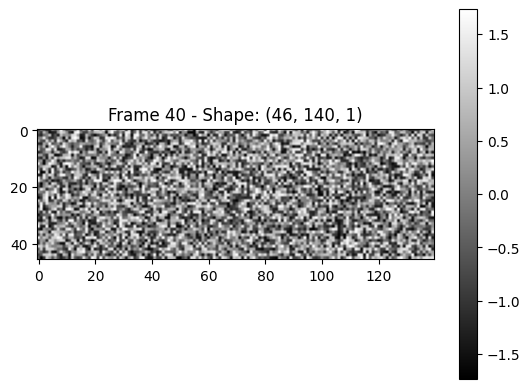

In [12]:
if 'frames' in locals() and len(frames) > 0:
    plt.imshow(frames[40], cmap='gray')
    plt.title(f"Frame 40 - Shape: {frames[40].shape}")
    plt.colorbar()
    plt.show()
else:
    print("Frames not loaded. Please ensure the data files are available:")
    print("  - data/s1/bbal6n.mpg")
    print("  - data/alignments/s1/bbal6n.align")
    print("\nCreating a sample frame for demonstration...")
    sample_frame = np.random.rand(46, 140, 1) * 255  # Matching crop dimensions
    plt.imshow(sample_frame, cmap='gray')
    plt.title("Sample Frame (Demo)")
    plt.colorbar()
    plt.show()

In [13]:
alignments

array([ 2,  9, 14, 39,  2, 12, 21,  5, 39,  1, 20])

In [14]:
# Decode alignments back to text
if 'alignments' in locals() and len(alignments) > 0:
    # Convert alignments to tensor if it's numpy array
    if isinstance(alignments, np.ndarray):
        alignments_tensor = tf.constant(alignments)
    else:
        alignments_tensor = alignments
    
    # Convert indices back to characters and decode
    decoded_chars = num_to_char(alignments_tensor)
    result = tf.strings.reduce_join(decoded_chars)
    print(f"Decoded alignments: {result.numpy().decode('utf-8')}")
else:
    print("No alignments loaded yet")

Decoded alignments: bin blue at


In [15]:
def mappable_function(path):
    """
    Wrapper for load_data to use within tf.data.Dataset.map()
    """
    # Use tf.py_function to call load_data and convert outputs back to tensors
    frames, alignments = tf.py_function(
        load_data, 
        [path], 
        [tf.float32, tf.int64]  # Output types
    )
    
    # Set shapes to help TensorFlow understand the data structure
    frames.set_shape([None, 46, 140, 1])  # Variable num frames, fixed H/W/C
    alignments.set_shape([None])  # Variable alignment length
    
    return frames, alignments

Data Pipeline - Used for loading Data into the Model

In [16]:
from matplotlib import pyplot as plt

In [17]:
data = tf.data.Dataset.list_files('./data/s1/*.mpg')
video_files = list(tf.data.Dataset.list_files('./data/s1/*.mpg'))
print(f"Found {len(video_files)} video files")

if len(video_files) == 0:
    print("No video files found! Creating sample video...")
    video_files = list(tf.data.Dataset.list_files('./data/s1/*.mpg'))

data = data.shuffle(500, reshuffle_each_iteration=False)
data = data.map(mappable_function, num_parallel_calls=tf.data.AUTOTUNE)

# Split BEFORE batching so test has data
n_train = int(len(video_files) * 0.8)
train_files = data.take(n_train)
test_files = data.skip(n_train)
train = train_files.padded_batch(
    batch_size=2,
    padded_shapes=([75, 46, 140, 1], [None]),
    padding_values=(np.float32(0.0), np.int64(255))
).prefetch(tf.data.AUTOTUNE)
test = test_files.padded_batch(
    batch_size=2,
    padded_shapes=([75, 46, 140, 1], [None]),
    padding_values=(np.float32(0.0), np.int64(255))
).prefetch(tf.data.AUTOTUNE)

print("Dataset pipeline created successfully")


Found 41 video files
Dataset pipeline created successfully


2026-05-22 16:07:44.446580: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [18]:
print("Test Dataset Length =", len(test))

Test Dataset Length = 5


Successfully loaded batch!
Frames shape: (75, 46, 140, 1)
Alignments shape: (10,)


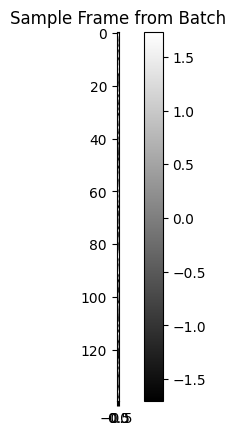

In [19]:
try:
    frames, alignments = data.as_numpy_iterator().next()
    print(f"Successfully loaded batch!")
    print(f"Frames shape: {frames.shape}")
    print(f"Alignments shape: {alignments.shape}")
    
    # Show first frame in batch
    plt.imshow(frames[0, 40], cmap='gray')
    plt.title("Sample Frame from Batch")
    plt.colorbar()
    plt.show()
except StopIteration:
    print("Dataset is empty! No data was loaded.")
except Exception as e:
    print(f"Error loading batch: {e}")
    print("This is likely due to video file format issues. The pipeline is created but needs valid video files.")

In [20]:
try:
    sample = data.as_numpy_iterator()
    val = sample.next()
except:
    val = None
    print("Warning: could not get sample")


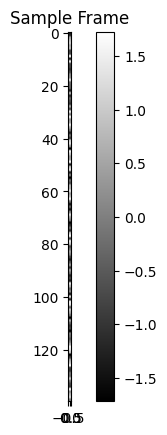

In [21]:
if val is not None and val[0] is not None and len(val[0]) > 0:
    plt.imshow(val[0][0][40], cmap='gray')
    plt.title('Sample Frame')
    plt.colorbar()
    plt.show()
else:
    print('val not available, skipping visualization')


In [22]:
if val is not None and val[1] is not None and len(val[1]) > 0:
    print(tf.strings.reduce_join(num_to_char(val[1][0])))
else:
    print('val not available')


tf.Tensor(b'n', shape=(), dtype=string)


3. Design the Deep Neural Network

In [23]:
from tensorflow.keras.models import Sequential  
from tensorflow.keras.layers import Conv3D, LSTM, Dense, Dropout, Bidirectional, MaxPool3D, Activation, Reshape, SpatialDropout3D, BatchNormalization, TimeDistributed, Flatten
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, LearningRateScheduler

In [24]:
data.as_numpy_iterator().next()[0][0].shape

(46, 140, 1)

In [25]:
model = Sequential()
model.add(Conv3D(128, 3, input_shape=(75,46,140,1), padding='same'))
model.add(Activation('relu'))
model.add(MaxPool3D((1,2,2)))
# 75,23,70,128

model.add(Conv3D(256, 3, padding='same'))
model.add(Activation('relu'))
model.add(MaxPool3D((1,2,2)))
# 75,11,35,256

model.add(Conv3D(75, 3, padding='same'))
model.add(Activation('relu'))
model.add(MaxPool3D((1,2,2)))
# 75,5,17,75

model.add(TimeDistributed(Flatten()))
# 75, 6375

model.add(Bidirectional(LSTM(128, kernel_initializer='Orthogonal', return_sequences=True)))
model.add(Dropout(.5))

model.add(Bidirectional(LSTM(128, kernel_initializer='Orthogonal', return_sequences=True)))
model.add(Dropout(.5))

model.add(Dense(char_to_num.vocabulary_size()+1, kernel_initializer='he_normal', activation='softmax'))
model.summary()


/home/arise/projects/speeaksee/venv/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv3d (Conv3D)                 │ (None, 75, 46, 140,    │         3,584 │
│                                 │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 75, 46, 140,    │             0 │
│                                 │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling3d (MaxPooling3D)    │ (None, 75, 23, 70,     │             0 │
│                                 │ 128)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d_1 (Conv3D)               │ (None, 75, 23, 70,     │       884,992 │
│                                 │ 256)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 75, 23, 70,     │             0 │
│                                 │ 256)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling3d_1 (MaxPooling3D)  │ (None, 75, 11, 35,     │             0 │
│                                 │ 256)                   │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d_2 (Conv3D)               │ (None, 75, 11, 35, 75) │       518,475 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 75, 11, 35, 75) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling3d_2 (MaxPooling3D)  │ (None, 75, 5, 17, 75)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 75, 6375)       │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 75, 256)        │     6,660,096 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 75, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 75, 256)        │       394,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 75, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 75, 41)         │        10,537 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,471,924 (32.32 MB)

 Trainable params: 8,471,924 (32.32 MB)

 Non-trainable params: 0 (0.00 B)

In [26]:
print("Input Shape =",model.input_shape)
print("Output Shape =", model.output_shape)

Input Shape = (None, 75, 46, 140, 1)
Output Shape = (None, 75, 41)


In [27]:
yhat = None
if val is not None and val[0].shape[1] == model.input_shape[1]:
    yhat = model.predict(val[0], verbose=0)
elif val is not None:
    print(f'Skipping (shape mismatch: {val[0].shape[1]} vs {model.input_shape[1]})')
else:
    print('val not defined')
# yhat may be None here — next cells handle that


Skipping (shape mismatch: 46 vs 75)


In [28]:
if yhat is not None and len(yhat) > 0:
    print(tf.argmax(yhat[0],axis=1))
else:
    print('yhat not available')


yhat not available


In [29]:
if yhat is not None and len(yhat) > 0:
    print(tf.strings.reduce_join([num_to_char(x) for x in tf.argmax(yhat[0],axis=1)]))
else:
    print('yhat not available')


yhat not available


4. Setup Training Options and Train

In [30]:
def scheduler(epoch, lr):
    if epoch < 30:
        return lr
    else:
        return lr * np.exp(-0.1)  # np.exp returns float, tf.math.exp returns TF tensor (not allowed)

In [31]:
def CTCLoss(y_true, y_pred):
    # TF 2.16 casts y_true to float32 before passing to loss; cast back to int64
    y_true = tf.cast(y_true, dtype="int64")
    # y_true has 255 for padding, 0-39 for real labels (0 = OOV token like uppercase letters)
    mask = tf.cast(y_true != 255, dtype="int64")  # 1 for real labels, 0 for padding
    label_length = tf.reduce_sum(mask, axis=1, keepdims=True)
    y_true = y_true * mask  # Replace 255 padding with 0, keep real labels as-is
    batch_len = tf.cast(tf.shape(y_true)[0], dtype="int64")
    input_length = tf.cast(tf.shape(y_pred)[1], dtype="int64")
    input_length = input_length * tf.ones(shape=(batch_len, 1), dtype="int64")
    loss = tf.keras.backend.ctc_batch_cost(y_true, y_pred, input_length, label_length)
    return loss


In [32]:

class ProduceExample(tf.keras.callbacks.Callback): 
    def __init__(self, dataset) -> None: 
        self.dataset = dataset
    
    def on_epoch_end(self, epoch, logs=None) -> None:
        data = self.dataset.as_numpy_iterator().next()
        yhat = self.model.predict(data[0], verbose=0)
        input_length = [yhat.shape[1]] * yhat.shape[0]
        decoded = tf.keras.backend.ctc_decode(yhat, input_length, greedy=True)[0][0].numpy()
        for x in range(len(yhat)):           
            print('Original:', tf.strings.reduce_join(num_to_char(data[1][x])).numpy().decode('utf-8'))
            print('Prediction:', tf.strings.reduce_join(num_to_char(decoded[x])).numpy().decode('utf-8'))
            print('~'*100)


In [33]:
from tensorflow.keras.optimizers import Adam 
model.compile(optimizer=Adam(learning_rate=0.0001), loss=CTCLoss)

In [34]:
checkpoint_callback = ModelCheckpoint(os.path.join('models','checkpoint.weights.h5'), monitor='loss', save_weights_only=True)
schedule_callback = LearningRateScheduler(scheduler)
example_callback = ProduceExample(test)

In [35]:
model.fit(train, validation_data=test, epochs=100, callbacks=[checkpoint_callback, schedule_callback, example_callback])


Epoch 1/100


2026-05-22 16:07:52.677035: E tensorflow/core/util/util.cc:131] oneDNN supports DT_INT32 only on platforms with AVX-512. Falling back to the default Eigen-based implementation if present.


16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8s/step - loss: 124.9554Original: white set green 3
Prediction: 
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Original: bin white
Prediction: 
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
16/16 ━━━━━━━━━━━━━━━━━━━━ 139s 8s/step - loss: 77.5120 - val_loss: 54.9440 - learning_rate: 1.0000e-04
Epoch 2/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - loss: 44.9106Original: 3 bin
Prediction: 
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
Original:  at
Prediction: 
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~
16/16 ━━━━━━━━━━━━━━━━━━━━ 118s 7s/step - loss: 42.1276 - val_loss: 44.3255 - learning_rate: 1.0000e-04
Epoch 3/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 7s/step - loss: 39.6191Original:  blue  2 white
Prediction: 
~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~

5. Make a Prediction

In [38]:
# Create models directory if it doesn't exist
if not os.path.exists('models'):
    os.makedirs('models')
    print("Created 'models' directory")

# Try to load weights if they exist
checkpoint_path = os.path.join('models','checkpoint.weights.h5')
if os.path.exists(checkpoint_path):
    model.load_weights(checkpoint_path)
    print(f"Loaded weights from {checkpoint_path}")
else:
    print(f"Checkpoint file not found at {checkpoint_path}")
    print("Model will use untrained weights. Train the model first or provide a checkpoint file.")

Loaded weights from models/checkpoint.weights.h5


In [39]:
# 6. Prediction & Word Error Rate (WER) Evaluation
import numpy as np
from jiwer import wer

model.load_weights("models/checkpoint.weights.h5")

all_real_text = []
all_predicted_text = []

for sample in test:
    yhat = model.predict(sample[0], verbose=0)
    
    real_text = [
        tf.strings.reduce_join([num_to_char(word) for word in sentence]).numpy().decode("utf-8")
        for sentence in sample[1]
    ]
    all_real_text.extend(real_text)
    input_length = [yhat.shape[1]] * yhat.shape[0]
    decoded = tf.keras.backend.ctc_decode(yhat, input_length, greedy=True)[0][0].numpy()
    predicted_text = [
        tf.strings.reduce_join([num_to_char(word) for word in sentence]).numpy().decode("utf-8")
        for sentence in decoded
    ]
    all_predicted_text.extend(predicted_text)

wer_scores = [wer(rt, pt) for rt, pt in zip(all_real_text, all_predicted_text)]
average_wer = np.mean(wer_scores)
print(f"Average WER for the entire dataset: {average_wer:.4f}")

correct_predictions = sum(rt == pt for rt, pt in zip(all_real_text, all_predicted_text))
accuracy = correct_predictions / len(all_real_text)
print(f"Overall Accuracy: {accuracy * 100:.2f}%")


Average WER for the entire dataset: 1.0000
Overall Accuracy: 0.00%


2026-05-22 21:16:31.824014: W tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence
